# 02. 탐색적 데이터 분석과 전처리 연결

예시 Notebook의 원칙대로 그래프를 나열하지 않고, 각 결과를 **관찰 → 다음 처리·실험 → 한계**로 연결합니다.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
train = pd.read_csv(ROOT / "data/train.csv")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Target 분포

관측 라벨의 규모를 확인해 지표와 불균형 처리 방향을 결정합니다.

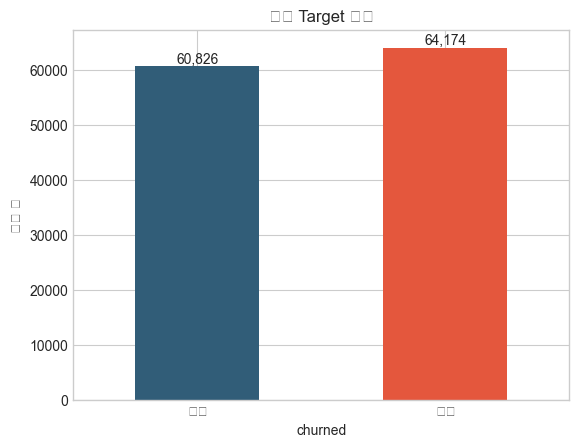

In [2]:
counts = train.churned.value_counts().sort_index()
ax = counts.rename({0: "유지", 1: "이탈"}).plot.bar(color=["#315d78", "#e4573d"], rot=0, title="관측 Target 분포")
ax.set_ylabel("고객 수")
for patch in ax.patches:
    ax.annotate(f"{int(patch.get_height()):,}", (patch.get_x()+patch.get_width()/2, patch.get_height()), ha="center", va="bottom")
plt.show()

**관찰:** 이탈이 51.3%로 과반이지만 극단적 희소 클래스는 아닙니다. **결정:** SMOTE보다 동일 Fold의 PR-AUC·Recall·오류량 비교를 우선합니다. **한계:** 제공 라벨의 관측 기간이 없어 실제 미래 이탈률로 해석하지 않습니다.

## 2. 구독 유형과 문의 수준

운영에서 행동으로 연결할 수 있는 범주형 신호를 확인합니다.

customer_service_inquiries,High,Low,Medium
subscription_type,,,
Family,59.3%,12.3%,32.0%
Free,96.4%,58.5%,83.3%
Premium,58.4%,13.2%,30.3%
Student,83.2%,31.5%,58.1%


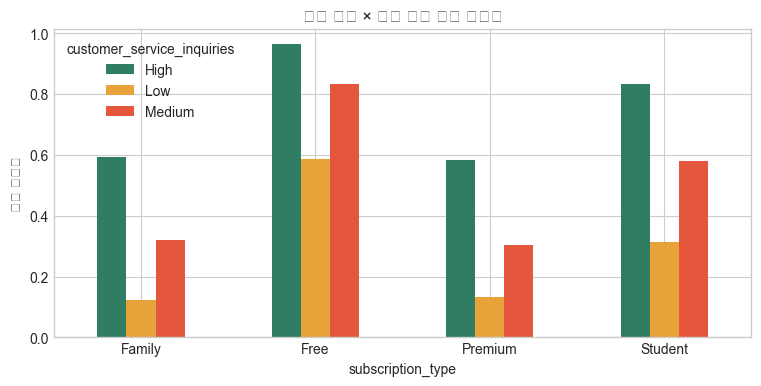

In [3]:
rates = (train.groupby(["subscription_type", "customer_service_inquiries"])["churned"]
         .mean().unstack().sort_index())
display(rates.style.format("{:.1%}"))
rates.plot.bar(figsize=(9, 4), color=["#2f7d62", "#e8a23a", "#e4573d"], title="구독 유형 × 문의 수준 관측 이탈률")
plt.ylabel("관측 이탈률")
plt.xticks(rotation=0)
plt.show()

**관찰:** Free와 높은 문의 수준에서 관측 이탈률이 높습니다. **결정:** 구독 옵션 안내와 문의 해결을 행동 후보에 연결하되, 모델과 행동 규칙은 분리합니다. **한계:** 합성 데이터의 연관성이므로 행동 효과나 인과 원인으로 단정하지 않습니다.

## 3. 주간 청취시간의 단계형 패턴

연속형 변수의 비선형성을 확인합니다.

,size,mean
hours_band,,
≤5h,12447,89.1%
5-10h,12536,72.5%
10-40h,75007,49.6%
>40h,25010,27.3%


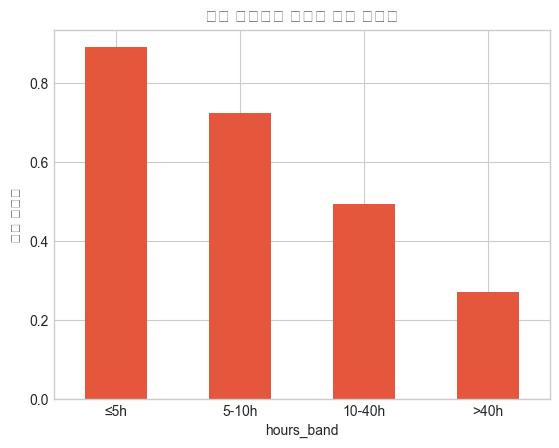

In [4]:
bins = [-1, 5, 10, 40, float("inf")]
labels = ["≤5h", "5-10h", "10-40h", ">40h"]
hours = train.assign(hours_band=pd.cut(train.weekly_hours, bins=bins, labels=labels))
hour_rate = hours.groupby("hours_band", observed=True).churned.agg(["size", "mean"])
display(hour_rate.style.format({"mean": "{:.1%}"}))
hour_rate["mean"].plot.bar(color="#e4573d", rot=0, title="주간 청취시간 구간별 관측 이탈률")
plt.ylabel("관측 이탈률")
plt.show()

**관찰:** 5·10·40시간 경계에서 계단형 차이가 나타납니다. **결정:** 선형 가정만 두지 않고 Tree Boosting과 log 변환 실험을 비교합니다. **한계:** 매끄러운 실사용 분포보다 합성 생성 규칙에 가까워 실서비스 재현을 보장하지 않습니다.

## 4. 신호와 노이즈의 구분

수치형 상관계수만으로 Feature를 제거하지 않고, 타깃 연관성과 예측 시점 가용성을 함께 봅니다.

In [5]:
numeric = train.select_dtypes("number").drop(columns=["customer_id"])
corr = numeric.corr(numeric_only=True)["churned"].drop("churned").sort_values(key=abs, ascending=False)
display(corr.to_frame("target_correlation").head(12).style.format("{:.4f}"))

,target_correlation
weekly_hours,-0.3025
num_subscription_pauses,0.1830
song_skip_rate,0.1602
age,0.0487
notifications_clicked,-0.0424
weekly_unique_songs,0.0194
average_session_length,-0.0065
num_favorite_artists,-0.0054
num_shared_playlists,0.0038
num_platform_friends,-0.0030


**관찰:** 선형 상관은 전반적으로 작지만 구간형 신호가 존재합니다. **결정:** 상관계수만으로 제거하지 않고 동일 Fold Feature 실험으로 채택 여부를 결정합니다. **한계:** Feature Importance도 인과성이 아니라 예측 기여도입니다.

## 5. EDA에서 모델링·운영으로 이어진 결정

| EDA 관찰 | 모델링 결정 | 운영 화면 연결 |
|---|---|---|
| 청취시간의 비선형 단계 | Logistic 기준선 + Boosting 비교 | 활동 저하 신호와 콘텐츠 재활성화 후보 |
| Free·Student 요금제 차이 | 범주형 처리와 CatBoost 후보 포함 | 구독 옵션 안내 |
| 높은 문의 수준 | 행동 가능 신호로 유지 | 문의 해결 우선 |
| 스킵률·일시정지 문턱 | Threshold형 Tree 모델 비교 | 추천 피드백·복귀 안내 |
| 합성·논리 위반 | 외부 Holdout과 인과 주장 제한 | KPI를 향후 검증 항목으로 표시 |

최종 결론은 `reports/preprocessing_report.md`, 모델 성능은 `reports/training_report.md`에서 확인합니다.